In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./cleaned_data.csv", sep=",")
df.head()

,calls_count_in_weekdays,calls_count_out_weekdays,calls_count_in_weekends,calls_count_out_weekends,DATA_VOLUME_WEEKDAYS,DATA_VOLUME_WEEKENDS,sim_count,AVG_ARPU,ROUM,phone_value,...,Brand_Samsung,Brand_Xiaomi,SCORING_Numeric,Is_Big_City_WORK,City_Population_Proxy_WORK,Raion_Density_WORK,Oblast_Density_HOME,Oblast_Density_WORK,Tech_Refresh_Rate,Affluence_Index
0,10.87,17.74,7.00,11.13,154.837,181.143,2.0,260.739450,0.0,3.0,...,1,0,3.0,1,698,702,936,945,0.629723,521.478900
1,0.91,0.48,0.25,0.75,53.639,49.009,2.0,52.635025,0.0,3.0,...,0,0,1.0,1,698,702,936,945,0.062292,105.270050
2,7.39,11.00,5.00,8.38,0.000,0.000,2.0,41.816525,0.0,4.0,...,0,0,1.0,0,1,94,1435,1428,0.288573,41.816525
3,0.43,0.70,2.25,0.00,0.000,0.000,2.0,39.863417,0.0,3.0,...,0,0,1.0,0,31,34,709,697,0.175305,79.726833
4,5.39,4.22,2.75,3.13,47.659,23.868,2.0,55.291350,0.0,3.0,...,0,0,1.0,1,1325,1325,1801,1813,0.087362,110.582700


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16794 entries, 0 to 16793
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   calls_count_in_weekdays      16794 non-null  float64
 1   calls_count_out_weekdays     16794 non-null  float64
 2   calls_count_in_weekends      16794 non-null  float64
 3   calls_count_out_weekends     16794 non-null  float64
 4   DATA_VOLUME_WEEKDAYS         16794 non-null  float64
 5   DATA_VOLUME_WEEKENDS         16794 non-null  float64
 6   sim_count                    16794 non-null  float64
 7   AVG_ARPU                     16794 non-null  float64
 8   ROUM                         16794 non-null  float64
 9   phone_value                  16794 non-null  float64
 10  car                          16794 non-null  int64  
 11  gender                       16794 non-null  int64  
 12  lifetime                     16794 non-null  float64
 13  how_long_same_mo

In [4]:
df['target'].value_counts()

target
4    4984
5    4810
3    3471
6    2168
2     936
1     425
Name: count, dtype: int64

<center><h1>КЛАСТЕРИЗАЦIЯ<h1><center>

In [5]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df)
print(X_scaled)

[[ 0.93288019  1.99931114  0.85142789 ... -0.28795108  2.65239679
   1.0778377 ]
 [-0.76396894 -0.82185147 -0.68483921 ... -0.28795108 -0.6382048
  -0.2497851 ]
 [ 0.34000519  0.89765204  0.39623764 ...  0.24752357  0.67402251
  -0.45218913]
 ...
 [-0.88152174 -0.736857   -0.74173799 ... -0.28795108 -0.57717958
  -0.1015246 ]
 [-0.06035579  0.14414338 -0.22964896 ... -1.04404572 -0.84250083
  -0.38941491]
 [ 1.86648794  4.31541045 -0.42765672 ... -0.61832675 -0.05862339
   0.19436833]]


In [6]:
from sklearn.metrics import pairwise_distances
pd.DataFrame(pairwise_distances(X_scaled))

,0,1,2,3,4,5,6,7,8,9,...,16784,16785,16786,16787,16788,16789,16790,16791,16792,16793
0,0.000000,13.771050,12.537474,12.544047,12.749862,12.526290,13.155987,13.194493,13.535655,13.110275,...,11.415051,16.964743,12.452041,11.554569,11.260761,13.480030,12.928440,12.724783,12.887762,11.154409
1,13.771050,0.000000,9.489297,8.123969,7.965907,8.931840,9.207637,9.964765,9.473500,9.394214,...,8.084155,13.368529,10.331985,8.808392,9.504629,9.848345,8.532145,10.323185,8.057078,10.226230
2,12.537474,9.489297,0.000000,6.495735,7.358596,5.779921,4.882073,10.456508,5.006213,7.974397,...,7.194612,15.083100,8.349215,7.933947,8.894977,6.565473,8.305734,10.951356,9.444655,8.562970
3,12.544047,8.123969,6.495735,0.000000,7.127623,6.952520,6.206284,10.322810,6.920498,6.202716,...,6.045367,14.526502,6.963424,6.648998,8.580374,6.730077,6.689043,9.596169,8.756619,8.969589
4,12.749862,7.965907,7.358596,7.127623,0.000000,8.492057,7.887367,10.496157,8.327005,8.328656,...,7.765283,14.714834,8.956015,8.172546,6.516096,9.605735,8.453593,8.808520,9.376609,9.185060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16789,13.480030,9.848345,6.565473,6.730077,9.605735,6.123043,6.127790,10.443495,5.242744,9.346041,...,7.238539,15.291056,9.184794,7.567781,10.615726,0.000000,9.143414,11.379912,10.158510,9.882454
16790,12.928440,8.532145,8.305734,6.689043,8.453593,8.256661,8.489112,9.002534,8.875192,5.894151,...,6.628035,14.142197,8.586846,7.635659,9.080727,9.143414,0.000000,9.329729,9.086406,8.824095
16791,12.724783,10.323185,10.951356,9.596169,8.808520,10.233004,10.854821,11.303762,11.469339,8.221946,...,9.148938,15.670558,10.340185,8.590742,9.106138,11.379912,9.329729,0.000000,10.312691,10.462677
16792,12.887762,8.057078,9.444655,8.756619,9.376609,10.101397,9.220162,10.932452,9.256198,8.887897,...,8.432575,13.903328,10.036511,8.524234,9.290388,10.158510,9.086406,10.312691,0.000000,9.157407


### Ієрархічна кластеризація
Будуємо дендрограму, щоб візуально оцінити структуру даних та визначити оптимальну кількість кластерів.
* **Метод Ward:** Мінімізує дисперсію всередині кластерів, що дає найбільш компактні та роздільні групи.
* **Аналіз графіка:**
  * Ми бачимо чіткий поділ на **3 великі гілки** (помаранчева, зелена, червона), що підказує нам оптимальне число кластерів k=3.

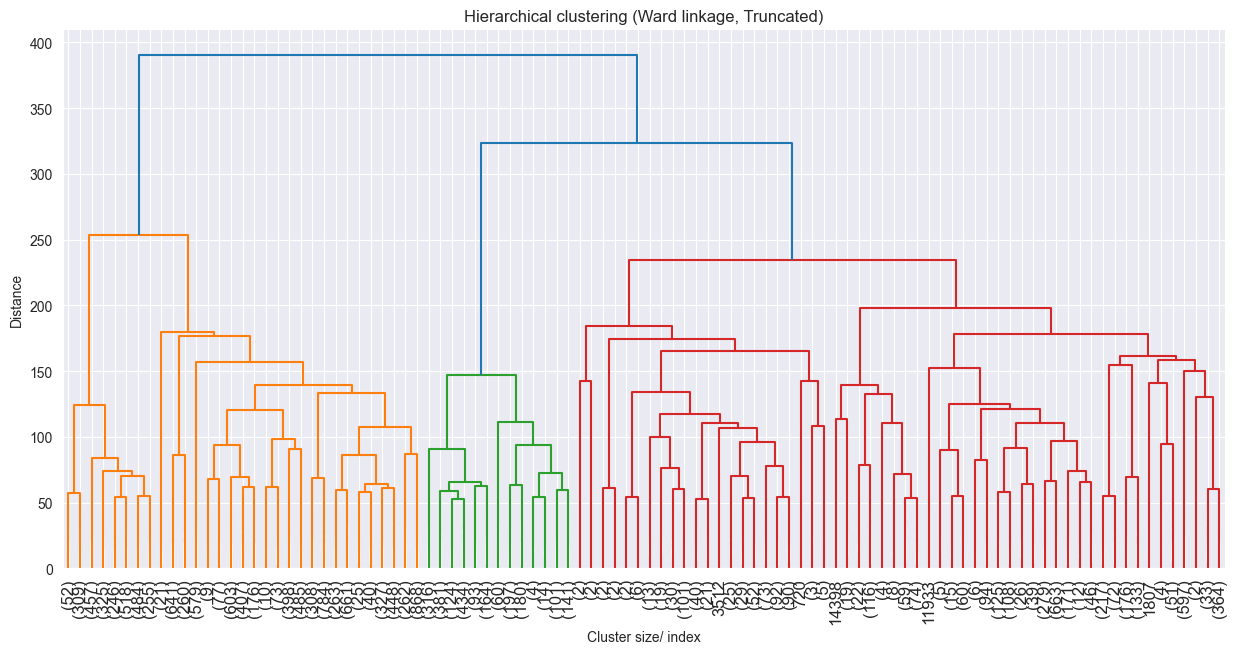

In [7]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

merging = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    merging,
    truncate_mode='lastp',
    p=100,
    leaf_rotation=90,
    leaf_font_size=12,
    show_contracted=True
)

plt.title('Hierarchical clustering (Ward linkage, Truncated)')
plt.xlabel('Cluster size/ index')
plt.ylabel('Distance')
plt.show()

In [8]:
clusters = fcluster(merging, 300, criterion='distance')
print(clusters)

[3 3 1 ... 1 3 3]


In [9]:
df_to_claster = df.copy()

df_to_claster['label'] = clusters
print(df_to_claster.sort_values('label')['label'])

16784    1
16783    1
16782    1
16781    1
16780    1
        ..
1        3
16792    3
16793    3
0        3
16788    3
Name: label, Length: 16794, dtype: int32


### K-Means Кластеризація
Застосовуємо алгоритм K-Means для розділення бази на 3 сегменти (на основі висновків з дендрограми).
* **Результат:** Отримуємо мітки кластерів (0, 1, 2) для кожного абонента.
* **Розподіл:**
    * **Кластер 1:** Найбільший (10 542 абонентів). Це "Масовий сегмент".
    * **Кластер 0:** (4 123 абонентів). Швидше за все, це "Молодь/Активні".
    * **Кластер 2:** (2 129 абонентів). Ймовірно, "Преміум" або "Специфічні" (високий ARPU або унікальна поведінка).

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

dict(zip(df_to_claster.index, labels))

{0: np.int32(2),
 1: np.int32(0),
 2: np.int32(0),
 3: np.int32(0),
 4: np.int32(1),
 5: np.int32(0),
 6: np.int32(0),
 7: np.int32(2),
 8: np.int32(0),
 9: np.int32(0),
 10: np.int32(0),
 11: np.int32(0),
 12: np.int32(0),
 13: np.int32(0),
 14: np.int32(0),
 15: np.int32(1),
 16: np.int32(0),
 17: np.int32(0),
 18: np.int32(1),
 19: np.int32(1),
 20: np.int32(0),
 21: np.int32(0),
 22: np.int32(0),
 23: np.int32(0),
 24: np.int32(0),
 25: np.int32(1),
 26: np.int32(0),
 27: np.int32(0),
 28: np.int32(0),
 29: np.int32(1),
 30: np.int32(0),
 31: np.int32(0),
 32: np.int32(0),
 33: np.int32(0),
 34: np.int32(2),
 35: np.int32(0),
 36: np.int32(1),
 37: np.int32(2),
 38: np.int32(0),
 39: np.int32(0),
 40: np.int32(1),
 41: np.int32(1),
 42: np.int32(0),
 43: np.int32(0),
 44: np.int32(1),
 45: np.int32(0),
 46: np.int32(0),
 47: np.int32(1),
 48: np.int32(0),
 49: np.int32(0),
 50: np.int32(2),
 51: np.int32(0),
 52: np.int32(0),
 53: np.int32(2),
 54: np.int32(1),
 55: np.int32(1),
 5

In [11]:
pd.Series(labels).value_counts().sort_index()

0    10542
1     4124
2     2128
Name: count, dtype: int64

### Метод "Ліктя" (Elbow Method)
Перевіряємо, чи дійсно k=3 є оптимальним вибором.
* **Висновок:** Графік має характерний злам ("лікоть") в точці **3 або 4**. Після цього додавання нових кластерів вже не дає суттєвого покращення якості розбиття. Ми залишаємось на 3.

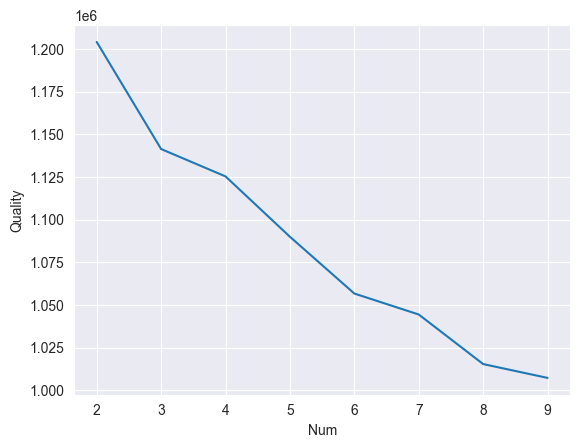

In [12]:
crit = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=15)
    kmeans.fit(X_scaled)
    crit.append(kmeans.inertia_)

plt.plot(range(2,10), crit)
plt.xlabel('Num')
plt.ylabel('Quality')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_scaled)
labels = kmeans.predict(X_scaled)

print(pd.DataFrame(labels, df.index))

       0
0      1
1      0
2      0
3      0
4      2
...   ..
16789  0
16790  0
16791  2
16792  0
16793  0

[16794 rows x 1 columns]


### Візуалізація кластерів (PCA)
Використовуємо метод головних компонент (PCA) для зниження розмірності з N ознак до 2D площини.
* **Кольори:** Показують приналежність до кластерів K-Means.
* **Червоні точки:** Центроїди кластерів.
* **Інтерпретація:**
    * Ми бачимо три чітко розділені "хмари" точок.
    * **Зелена хмара (справа):** Найбільш масивна, ймовірно, це звичайні користувачі.
    * **Фіолетова хмара (зліва):** Чітко відокремлена. Це може бути "Цифрова молодь".
    * **Оливкова хмара (зверху):** Проміжна група.
Це підтверджує, що наша сегментація має фізичний сенс, а не є випадковою.

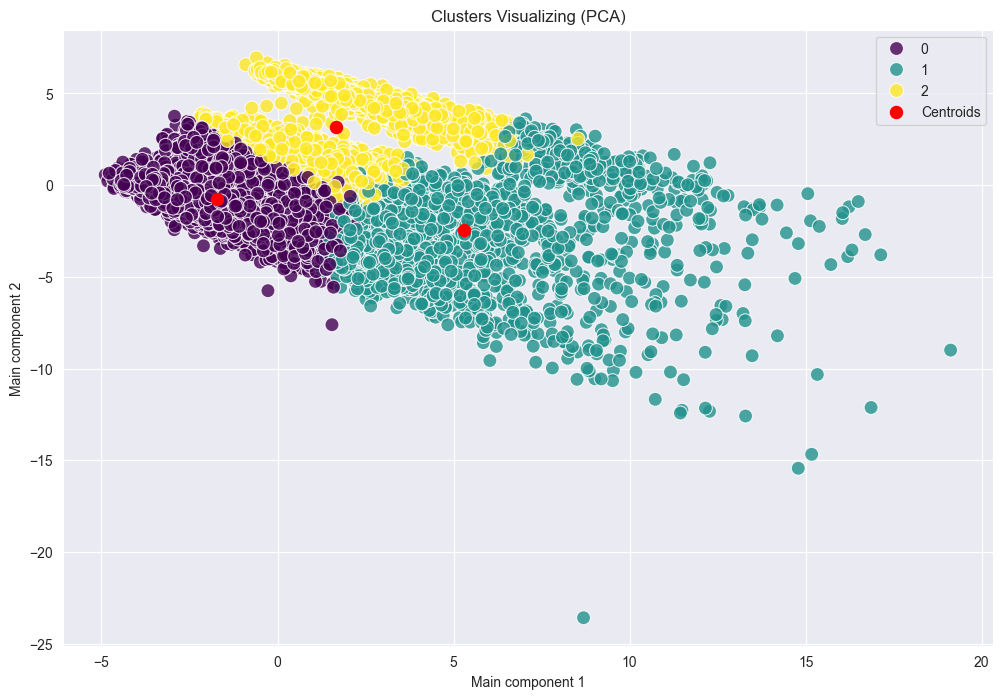

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='.',
    s=300,
    c='red',
    label='Centroids'
)

plt.title('Clusters Visualizing (PCA)')
plt.xlabel('Main component 1')
plt.ylabel('Main component 2')
plt.legend()
plt.grid(True)
plt.show()

<center><h1>ТРЕНУВАННЯ МОДЕЛЕЙ<h1><center>

<center><h2>RF, MLP, LogReg, GradBoost<h2><center>

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# results['6_classes']['RF'] = {model, pred, metric}
history = {}

In [172]:
y_orig = df['target']
X = df.drop(columns=['target'], errors='ignore')

# 1 -> Youth(0),
# 2 -> Students(1)
# 3, 4, 5->Adults(2),
# 6->Seniors(3)
group_map = {1: 0,
             2: 1,
             3: 2, 4: 2, 5: 2,
             6: 3}
y_grouped = df['target'].map(group_map)

scenarios = [
    ('6_classes', y_orig, ['1', '2', '3', '4', '5', '6']),
    ('4_classes', y_grouped, ['Youth', 'Students', 'Adults', 'Seniors'])
]

### Навчання моделей:
Проводимо порівняльний аналіз 4-х класичних алгоритмів ML для вирішення задачі вікової класифікації.
**Ключові висновки за результатами:**
* **Тріумф 4-х класів:** F1-score зріс з приблизно 40% (на 6 класах) до **77%** (на 4 класах). Це підтверджує, що об'єднання груп 3-4-5 було стратегічно вірним рішенням.
* **Лідер:** **Gradient Boosting** показав найкращий результат (**F1=0.77**), обійшовши навіть Random Forest.
* **Якість даних:** Logistic Regression показала результат **74.8%**, що майже на рівні складних моделей. Це свідчить про те, що створені фічі (`Affluence_Index`, `Commute`, `Tech_Refresh`) мають дуже сильну передбачувальну силу.

In [173]:
for name, y_target, class_names in scenarios:
    print(f"\n{'='*60}")
    print(f"SCENARIO: {name}")
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_target, test_size=0.2, random_state=2025, stratify=y_target
    )

    # Scaling for LogReg and MLP
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    history[name] = {
        'y_test': y_test,
        'names': class_names,
        'models': {},
        'preds': {},
        'metrics': {}
    }

    # --- 1. RANDOM FOREST ---
    print("\nHyperparameter selection for RF...")
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [8, 12, None],
        'class_weight': ['balanced']
    }
    grid_rf = GridSearchCV(RandomForestClassifier(random_state=2025), rf_params, cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)

    f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

    history[name]['models']['RF'] = best_rf
    history[name]['preds']['RF'] = y_pred_rf
    history[name]['metrics']['RF'] = f1_rf

    print(f"\tBEST RF F1-Score: {f1_rf:.4f}")
    print(f"\tBEST PARAMS: {grid_rf.best_params_}")


    # --- 2. MLP NEURAL NET ---
    print("\nHyperparameter selection for MLP Neural Network...")
    mlp_params = {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'alpha': [0.0001, 0.01],
        'learning_rate_init': [0.001, 0.01]
    }
    rand_mlp = RandomizedSearchCV(MLPClassifier(max_iter=500, random_state=42), mlp_params, n_iter=5, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=2025)
    rand_mlp.fit(X_train_scaled, y_train)

    best_mlp = rand_mlp.best_estimator_
    y_pred_mlp = best_mlp.predict(X_test_scaled)

    f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted')

    history[name]['models']['MLP'] = best_mlp
    history[name]['preds']['MLP'] = y_pred_mlp
    history[name]['metrics']['MLP'] = f1_mlp

    print(f"\tBEST MLP F1-Score: {f1_mlp:.4f}")
    print(f"\tBEST PARAMS: {rand_mlp.best_params_}")


    # --- 3. LOGISTIC REGRESSION ---
    print("\nHyperparameter selection for Logistic Regression...")
    lr_params = {
        'C': [0.1, 1, 10],
        'class_weight': ['balanced', None]
    }
    grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=2025), lr_params, cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_lr.fit(X_train_scaled, y_train)

    best_lr = grid_lr.best_estimator_
    y_pred_lr = best_lr.predict(X_test_scaled)

    f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

    history[name]['models']['LogReg'] = best_lr
    history[name]['preds']['LogReg'] = y_pred_lr
    history[name]['metrics']['LogReg'] = f1_lr

    print(f"\tBEST LogReg F1-Score: {f1_lr:.4f}")
    print(f"\tBEST PARAMS: {grid_lr.best_params_}")

# --- 4. GRADIENT BOOSTING (sklearn) ---
    print("\nHyperparameter selection for  Gradient Boosting...")
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    }
    gb = GradientBoostingClassifier(random_state=2025)

    grid_gb = GridSearchCV(gb, gb_params, cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_gb.fit(X_train, y_train)

    best_gb = grid_gb.best_estimator_
    y_pred_gb = best_gb.predict(X_test)
    f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

    history[name]['models']['GradientBoosting'] = best_gb
    history[name]['preds']['GradientBoosting'] = y_pred_gb
    history[name]['metrics']['GradientBoosting'] = f1_gb

    print(f"\tBEST GradBoost F1-Score: {f1_gb:.4f}")
    print(f"\tBEST PARAMS: {grid_gb.best_params_}")



SCENARIO: 6_classes

Hyperparameter selection for RF...
	BEST RF F1-Score: 0.4056
	BEST PARAMS: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}

Hyperparameter selection for MLP Neural Network...
	BEST MLP F1-Score: 0.3661
	BEST PARAMS: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (50,), 'alpha': 0.01}

Hyperparameter selection for Logistic Regression...
	BEST LogReg F1-Score: 0.4027
	BEST PARAMS: {'C': 1, 'class_weight': None}

Hyperparameter selection for  Gradient Boosting...
	BEST GradBoost F1-Score: 0.4212
	BEST PARAMS: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

SCENARIO: 4_classes

Hyperparameter selection for RF...
	BEST RF F1-Score: 0.7501
	BEST PARAMS: {'class_weight': 'balanced', 'max_depth': 12, 'n_estimators': 200}

Hyperparameter selection for MLP Neural Network...
	BEST MLP F1-Score: 0.7374
	BEST PARAMS: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (50,), 'alpha': 0.01}

Hyperparameter selection for Logistic Regression.

### Матриці помилок
Оцінюємо якість класифікації.
* **Ефект 4-х класів (Нижній ряд):**
    * Ми бачимо чітку яскраву діагональ. Це означає, що моделі правильно вгадують більшість користувачів.
    * **Основна складність:** Усі моделі іноді плутають `Students` та `Adults`. Це логічно: 22-річний працюючий студент за поведінкою схожий на 25-річного молодого спеціаліста.

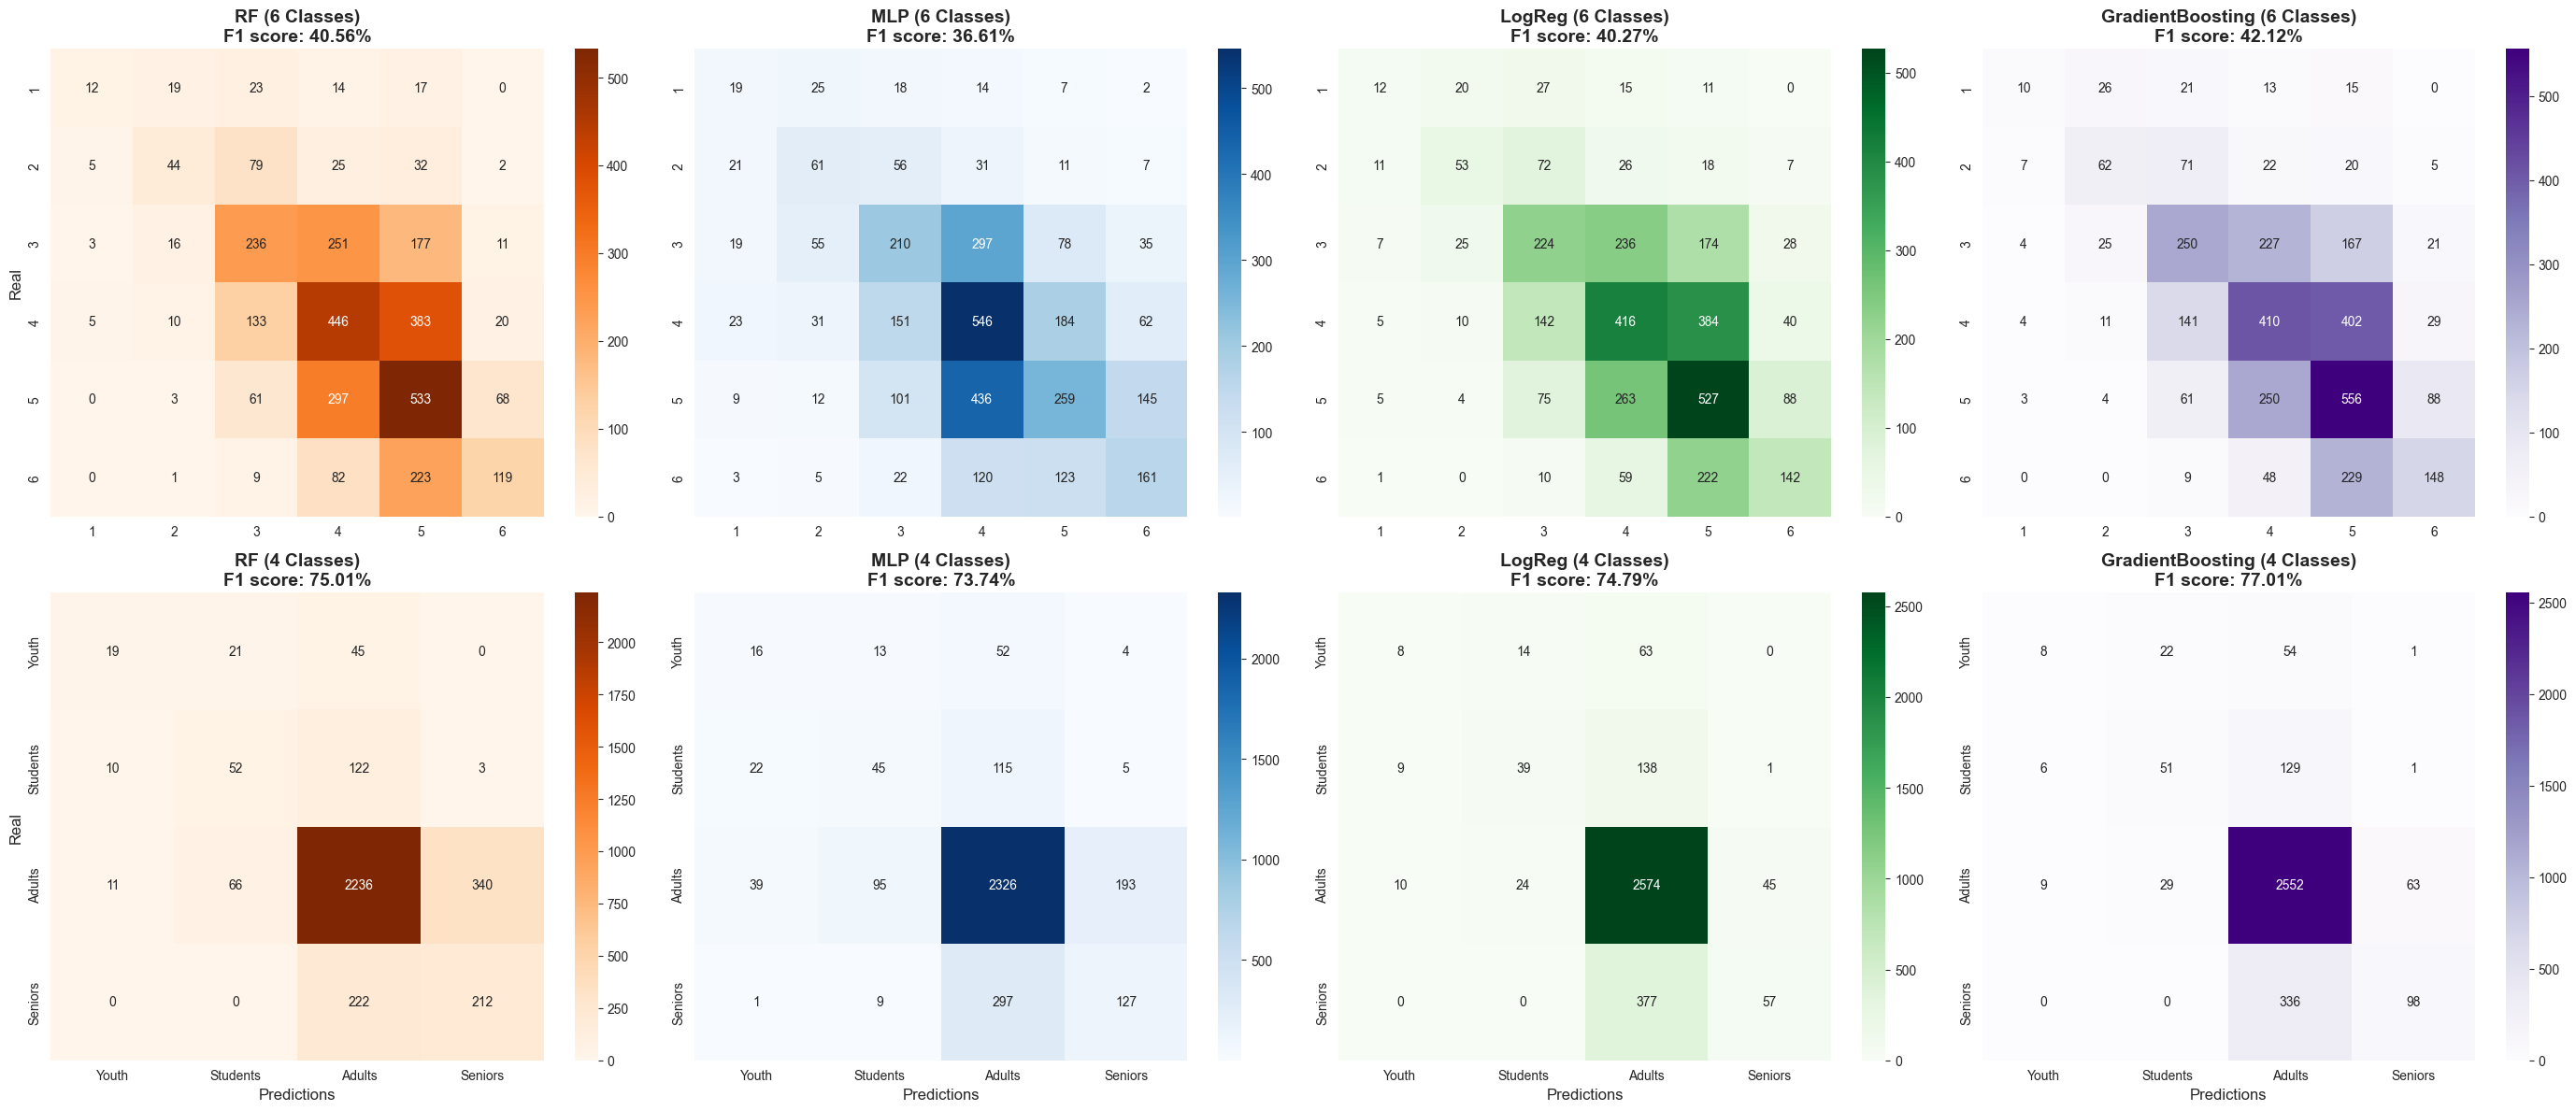

In [174]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

for row_idx, (scen_name, _, _) in enumerate(scenarios):
    data = history[scen_name]
    y_true = data['y_test']
    labels = data['names']

    models_list = ['RF', 'MLP', 'LogReg', 'GradientBoosting']
    colors = ['Oranges', 'Blues', 'Greens', 'Purples']

    for col_idx, model_name in enumerate(models_list):
        y_pred = data['preds'][model_name]
        f1_score = data['metrics'][model_name]
        ax = axes[row_idx, col_idx]

        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap=colors[col_idx], ax=ax,
                    xticklabels=labels, yticklabels=labels)

        if row_idx == 0:
            ax.set_title(f"{model_name} (6 Classes)\nF1 score: {f1_score:.2%}", fontsize=14, fontweight='bold')
        else:
            ax.set_title(f"{model_name} (4 Classes)\nF1 score: {f1_score:.2%}", fontsize=14, fontweight='bold')
            ax.set_xlabel('Predictions', fontsize=12)

        if col_idx == 0:
            ax.set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.show()

### 25. Важливість ознак: Що насправді впливає на вік?
1. **Абсолютний лідер (`lifetime`):**
   * Всі 4 моделі поставили **стаж абонента** на перше місце. Це підтверджує правило: молодь мігрує, старше покоління залишається вірним оператору.
2. **Маркери поколінь:**
   * **`instagram_volume` (2-ге місце):** Головний розділювач для молоді.
   * **`OS_Feature_Phone` (3-тє місце):** Наявність кнопочного телефону - точний маркер пенсіонерів.
3. **Географія та Гроші:**
   * Ознаки `Avg_Call_Duration` та `Weekend_Calls_Share` також у топі. Це означає, що **стиль спілкування** (довгі дзвінки у вихідні) важливіший для визначення віку, ніж просто район проживання.

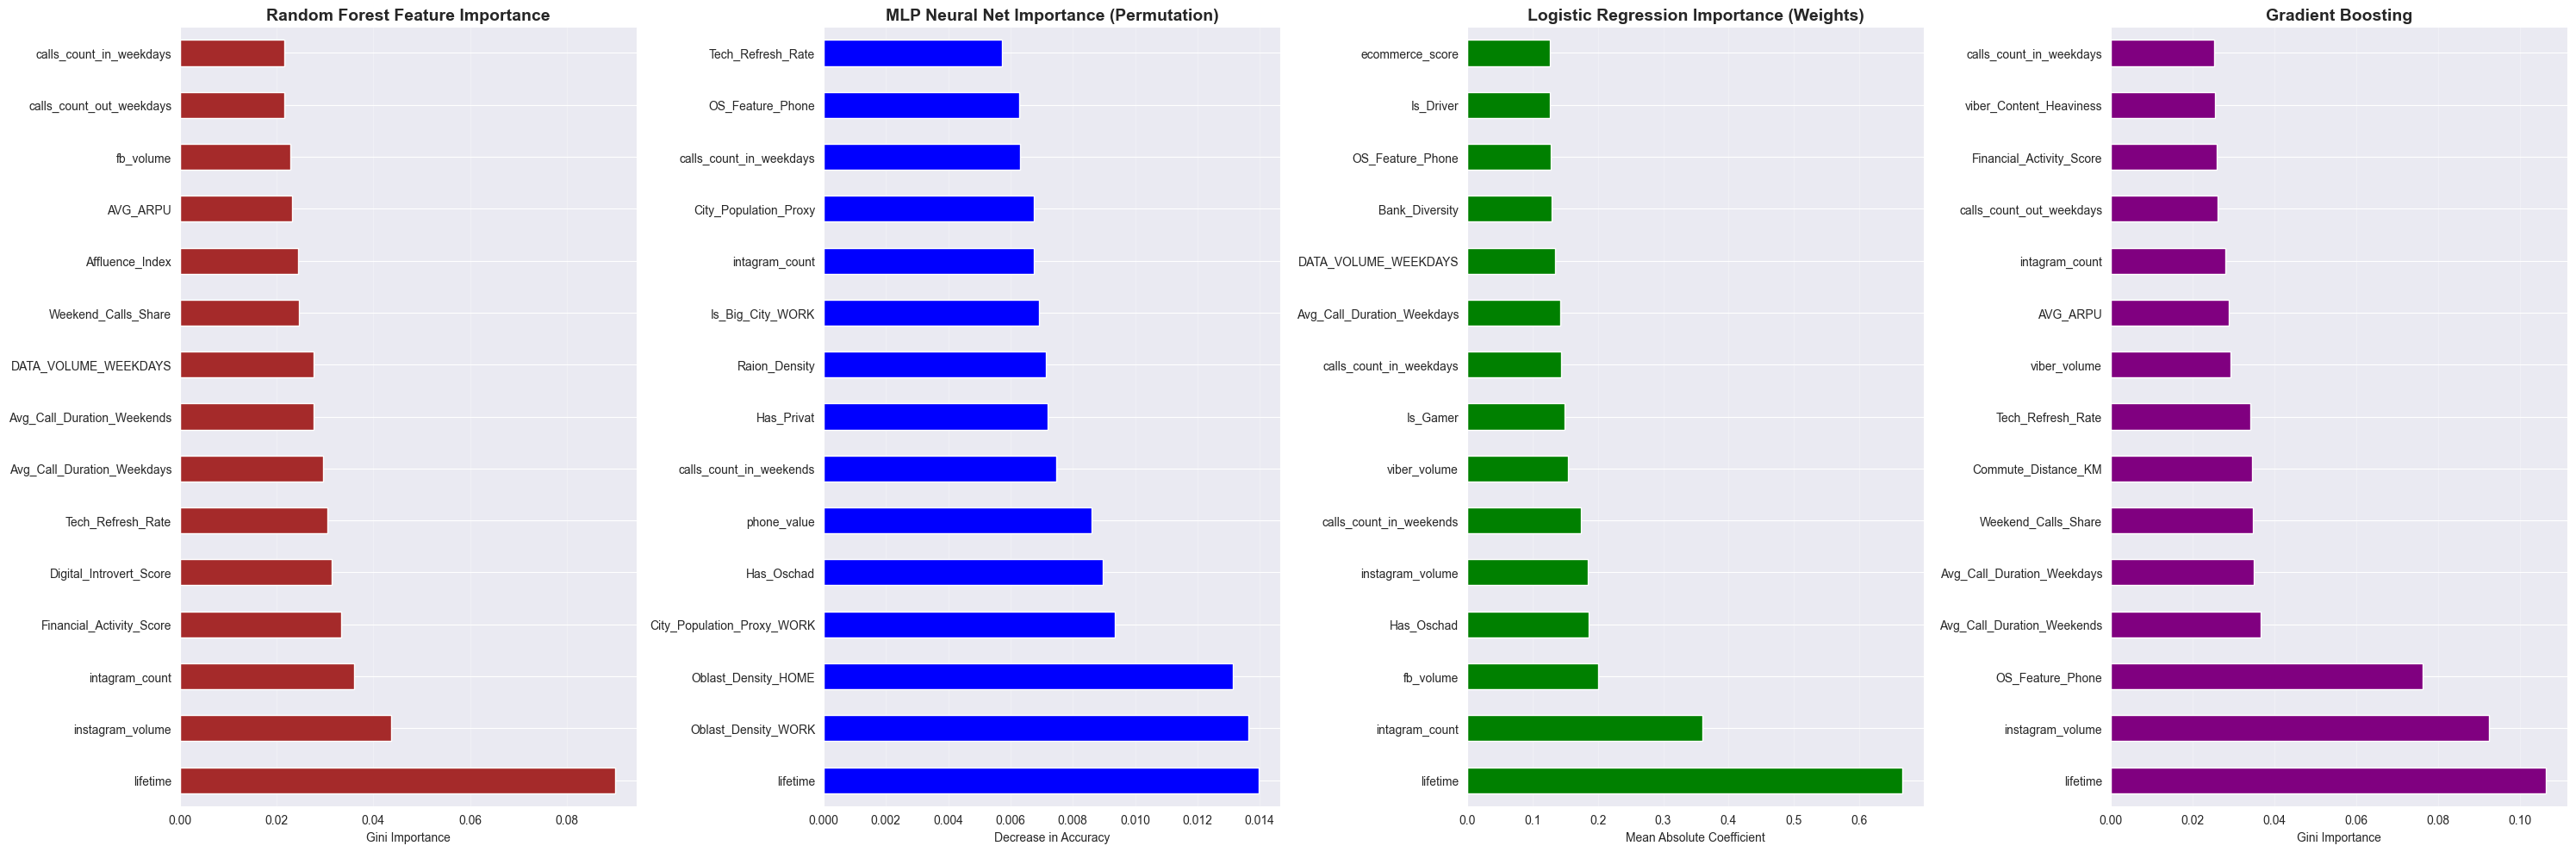

In [175]:
from sklearn.inspection import permutation_importance

# FOR 4 CLASSES
y_target = df['target'].map(group_map)
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X, y_target, test_size=0.2, random_state=2025, stratify=y_target
)

scaler = StandardScaler()
X_train_scaled_4 = scaler.fit_transform(X_train_4)
X_test_scaled_4 = scaler.transform(X_test_4)

best_rf = history['4_classes']['models']['RF']
best_mlp = history['4_classes']['models']['MLP']
best_lr = history['4_classes']['models']['LogReg']
best_gb = history['4_classes']['models']['GradientBoosting']

fig, ax = plt.subplots(1, 4, figsize=(30, 10))

# RF
feat_imp_rf = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp_rf.nlargest(15).plot(kind='barh', ax=ax[0], color='brown')
ax[0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Gini Importance')
ax[0].grid(axis='x', alpha=0.3)


# MLP (Permutation Importance)
perm_importance = permutation_importance(best_mlp, X_test_scaled_4, y_test_4, n_repeats=10, random_state=2025, n_jobs=-1)

feat_imp_mlp = pd.Series(perm_importance.importances_mean, index=X.columns)
feat_imp_mlp.nlargest(15).plot(kind='barh', ax=ax[1], color='blue')
ax[1].set_title('MLP Neural Net Importance (Permutation)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Decrease in Accuracy')
ax[1].set_ylabel('')
ax[1].grid(axis='x', alpha=0.3)


# Logistic Regression
lr_coeffs = np.mean(np.abs(best_lr.coef_), axis=0)
feat_imp_lr = pd.Series(lr_coeffs, index=X.columns)
feat_imp_lr.nlargest(15).plot(kind='barh', ax=ax[2], color='green')
ax[2].set_title('Logistic Regression Importance (Weights)', fontsize=14, fontweight='bold')
ax[2].set_xlabel('Mean Absolute Coefficient')
ax[2].set_ylabel('')
ax[2].grid(axis='x', alpha=0.3)

# Gradient Boosting

feat_imp_gb = pd.Series(best_gb.feature_importances_, index=X.columns)
feat_imp_gb.nlargest(15).plot(kind='barh', ax=ax[3], color='purple')
ax[3].set_title('Gradient Boosting', fontsize=14, fontweight='bold')
ax[3].set_xlabel('Gini Importance')
ax[3].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()